In [20]:
# Install necessary libraries
!pip install yfinance
!pip install feature_engine

# Clone the tensortrade repository if it doesn't already exist
import os

repo_name = 'tensortrade'
repo_url = 'https://github.com/a521206/tensortrade.git'

if not os.path.exists(repo_name):
    print(f"Cloning '{repo_name}' repository...")
    !git clone {repo_url}
else:
    print(f"'{repo_name}' repository already exists. Skipping clone.")

# Install dependencies from the cloned repository's requirements.txt
requirements_path = os.path.join(repo_name, 'requirements.txt')

if os.path.exists(requirements_path):
    print(f"Installing dependencies from '{requirements_path}'...")
    !pip install -r {requirements_path}
    print("Dependencies installed.")
else:
    print(f"Warning: '{requirements_path}' not found. Please check the repository structure.")

# Add the cloned tensortrade directory to the Python path
# This ensures that 'tensortrade' modules can be imported directly if needed
import sys
if repo_name not in sys.path:
    sys.path.insert(0, repo_name)
    print(f"Added '{repo_name}' to system path.")

from feature_engine.selection import SelectBySingleFeaturePerformance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 10.4 MB/s eta 0:00:00
'tensortrade' repository already exists. Skipping clone.
Installing dependencies from 'tensortrade/requirements.txt'...
Dependencies installed.


# Train and Evaluate Tutorial - Stocks

This notebook covers feature engineering, reward schemes, and training a DQN agent on stock trading data.

## 📚 Related Tutorials

Before diving in, review these essential tutorials:

| Tutorial | Description |
|----------|-------------|
| [First Training](../docs/tutorials/04-training/01-first-training.md) | Getting started with training |
| [Reward Schemes](../docs/tutorials/03-components/02-reward-schemes.md) | Why PBR works and reward design |
| [Common Failures](../docs/tutorials/02-domains/track-b-rl-for-traders/02-common-failures.md) | **Critical pitfalls to avoid** |
| [Overfitting](../docs/tutorials/05-advanced/01-overfitting.md) | Detection and prevention |
| [Commission Analysis](../docs/tutorials/05-advanced/02-commission.md) | Key finding: commission destroys profits |

### ⚠️ Important Warning

Our experiments show that agents **can predict market direction** but **overtrading destroys profits** when commission is applied. See the [Commission Analysis](../docs/tutorials/05-advanced/02-commission.md) tutorial for details.

---

## Define global variables

In [21]:
n_steps = 1000
n_episodes = 20
window_size = 30
memory_capacity = n_steps * 10
save_path = 'agents/'
n_bins = 5
seed = 1337
learning_rate = 1e-3
gamma = 0.99
eps_decay = 200



```
# This is formatted as code
```

It seems the `requirements.txt` file was not found because the `tensortrade` repository had not been cloned yet. I will clone the repository and then install its dependencies.

In [22]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f'GPU enabled: {torch.cuda.get_device_name(0)}')
    print(f'CUDA version: {torch.version.cuda}')
else:
    print('No GPU found, using CPU')

GPU enabled: Tesla T4
CUDA version: 12.8


## Setup Data Fetching

In [23]:
import yfinance as yf

import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")
pd.set_option('future.no_silent_downcasting', True)

def prepare_data(df):
    df['volume'] = np.int64(df['volume'])
    df['date'] = pd.to_datetime(df['date'])
    df.sort_values(by='date', ascending=True, inplace=True)
    df.reset_index(drop=True, inplace=True)
    df['date'] = df['date'].dt.strftime('%Y-%m-%d %I:%M %p')
    return df

def fetch_data(ticker='AAPL', period='2y', interval='1h'):
    stock = yf.Ticker(ticker)  # type: ignore[no-any-return]
    df = stock.history(period=period, interval=interval)  # type: ignore[no-any-return]
    df = df.reset_index()
    df = df.rename(columns={
        'Date': 'date',
        'Datetime': 'date',
        'Open': 'open',
        'High': 'high',
        'Low': 'low',
        'Close': 'close',
        'Volume': 'volume'
    })
    df = df[['date', 'open', 'high', 'low', 'close', 'volume']]
    df = prepare_data(df)
    return df

In [24]:
data = fetch_data('AAPL')
data

,date,open,high,low,close,volume
0,2024-07-16 09:30 AM,235.205002,236.270004,233.009995,233.830002,11433979
1,2024-07-16 10:30 AM,233.830002,234.910004,233.675003,234.160004,5219269
2,2024-07-16 11:30 AM,234.160004,234.350006,232.619995,232.947906,5683620
3,2024-07-16 12:30 PM,232.925003,233.797195,232.330002,233.544998,4383942
4,2024-07-16 01:30 PM,233.539993,234.550003,233.414993,234.389999,3187466
...,...,...,...,...,...,...
3473,2026-07-15 11:30 AM,325.609985,328.529999,325.160004,328.170013,7315724
3474,2026-07-15 12:30 PM,328.160004,328.500000,325.970001,326.989990,5967302
3475,2026-07-15 01:30 PM,327.000000,328.000000,326.649994,327.790009,3896347
3476,2026-07-15 02:30 PM,327.779999,328.720001,326.859985,327.059998,4546317


## Create features for the feed module

In [25]:
import ta
import ta.trend  # type: ignore[no-redef]

def fix_dataset_inconsistencies(dataframe, fill_value=None):
    dataframe = dataframe.replace([-np.inf, np.inf], np.nan)

    if fill_value is None:
        dataframe.iloc[0,:] = \
            dataframe.apply(lambda column: column.iloc[column.first_valid_index()], axis='index')
    else:
        dataframe.iloc[0,:] = \
            dataframe.iloc[0,:].fillna(fill_value)

    return dataframe.ffill().dropna(axis='columns')

def rsi(price: 'pd.Series', period: float) -> 'pd.Series':
    r = price.diff()
    upside = r.clip(lower=0)
    downside = -r.clip(upper=0)
    rs = upside.ewm(alpha=1 / period).mean() / downside.ewm(alpha=1 / period).mean()
    return 100*(1 - (1 + rs) ** -1)

def macd(price: 'pd.Series', fast: float, slow: float, signal: float) -> 'pd.Series':
    fm = price.ewm(span=fast, adjust=False).mean()
    sm = price.ewm(span=slow, adjust=False).mean()
    md = fm - sm
    signal = md - md.ewm(span=signal, adjust=False).mean()
    return signal

def generate_features(data):
    df = data.copy()

    ta.add_all_ta_features(df,
                            'open',
                            'high',
                            'low',
                            'close',
                            'volume',
                            fillna=True)

    df = df.rename(columns={'open': 'Open',
                                'high': 'High',
                                'low': 'Low',
                                'close': 'Close',
                                'volume': 'Volume'})
    df = df.set_index('date')

    features = pd.DataFrame.from_dict({
        'prev_open': df['Open'].shift(1),
        'prev_high': df['High'].shift(1),
        'prev_low': df['Low'].shift(1),
        'prev_close': df['Close'].shift(1),
        'prev_volume': df['Volume'].shift(1),
        'vol_5': df['Close'].rolling(window=5).std().abs(),
        'vol_10': df['Close'].rolling(window=10).std().abs(),
        'vol_20': df['Close'].rolling(window=20).std().abs(),
        'vol_30': df['Close'].rolling(window=30).std().abs(),
        'vol_50': df['Close'].rolling(window=50).std().abs(),
        'vol_60': df['Close'].rolling(window=60).std().abs(),
        'vol_100': df['Close'].rolling(window=100).std().abs(),
        'vol_200': df['Close'].rolling(window=200).std().abs(),
        'ma_5': df['Close'].rolling(window=5).mean(),
        'ma_10': df['Close'].rolling(window=10).mean(),
        'ma_20': df['Close'].rolling(window=20).mean(),
        'ma_30': df['Close'].rolling(window=30).mean(),
        'ma_50': df['Close'].rolling(window=50).mean(),
        'ma_60': df['Close'].rolling(window=60).mean(),
        'ma_100': df['Close'].rolling(window=100).mean(),
        'ma_200': df['Close'].rolling(window=200).mean(),
        'ema_5': ta.trend.ema_indicator(df['Close'], window=5, fillna=True),
        'ema_10': ta.trend.ema_indicator(df['Close'], window=10, fillna=True),
        'ema_20': ta.trend.ema_indicator(df['Close'], window=20, fillna=True),
        'ema_60': ta.trend.ema_indicator(df['Close'], window=60, fillna=True),
        'ema_64': ta.trend.ema_indicator(df['Close'], window=64, fillna=True),
        'ema_120': ta.trend.ema_indicator(df['Close'], window=120, fillna=True),
        'lr_open': np.log(df['Open']).diff().fillna(0),
        'lr_high': np.log(df['High']).diff().fillna(0),
        'lr_low': np.log(df['Low']).diff().fillna(0),
        'lr_close': np.log(df['Close']).diff().fillna(0),
        'r_volume': df['Close'].diff().fillna(0),
        'rsi_5': rsi(df['Close'], period=5),
        'rsi_10': rsi(df['Close'], period=10),
        'rsi_100': rsi(df['Close'], period=100),
        'rsi_7': rsi(df['Close'], period=7),
        'rsi_28': rsi(df['Close'], period=28),
        'rsi_6': rsi(df['Close'], period=6),
        'rsi_14': rsi(df['Close'], period=14),
        'rsi_26': rsi(df['Close'], period=24),
        'macd_normal': macd(df['Close'], fast=12, slow=26, signal=9),
        'macd_short': macd(df['Close'], fast=10, slow=50, signal=5),
        'macd_long': macd(df['Close'], fast=200, slow=100, signal=50),
    })

    data = pd.concat([df, features], axis='columns').ffill()

    data = data.loc[:,~data.columns.duplicated()]

    data = data.rename(columns={'Open': 'open',
                                'High': 'high',
                                'Low': 'low',
                                'Close': 'close',
                                'Volume': 'volume'})

    data = data.reset_index()

    data = data.iloc[200:]
    data = data.reset_index(drop=True)

    data = fix_dataset_inconsistencies(data, fill_value=None)
    return data

In [26]:
data = generate_features(data)
data

,date,open,high,low,close,volume,volume_adi,volume_obv,volume_cmf,volume_fi,...,rsi_10,rsi_100,rsi_7,rsi_28,rsi_6,rsi_14,rsi_26,macd_normal,macd_short,macd_long
0,2024-08-23 01:30 PM,225.970001,226.550003,225.949997,226.452698,2323736,9.665343e+07,46011685,0.027630,1.300380e+06,...,53.596869,52.066029,54.663152,54.990402,55.426735,53.551682,54.740325,-0.075718,-0.059414,-1.227211
1,2024-08-23 02:30 PM,226.455002,227.100006,226.220001,227.059998,2752049,9.915524e+07,48763734,0.077760,1.353372e+06,...,56.958245,52.432249,59.071916,56.273742,60.397271,56.112749,56.259111,0.000890,0.034244,-1.221205
2,2024-08-23 03:30 PM,227.065002,227.166901,226.229996,226.773605,3536618,9.972265e+07,45227116,0.037731,1.015339e+06,...,54.875372,52.242123,56.071952,55.499850,56.812108,54.584264,55.345195,0.028225,0.047005,-1.211526
3,2024-08-26 09:30 AM,227.210007,227.210007,224.477203,224.949997,6251104,9.563451e+07,38976012,0.010531,-7.582192e+05,...,43.596086,51.051465,40.712391,50.879425,39.084565,45.993176,49.953412,-0.074923,-0.129852,-1.183876
4,2024-08-26 10:30 AM,224.919998,225.190002,223.890503,225.070007,3930509,9.883914e+07,42906521,0.041081,-5.825162e+05,...,44.431265,51.125511,41.933605,51.156932,40.549544,46.588953,50.285996,-0.130238,-0.207546,-1.157896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3273,2026-07-15 11:30 AM,325.609985,328.529999,325.160004,328.170013,7315724,4.579078e+08,448225487,0.281517,1.712215e+07,...,79.198235,59.065163,84.245602,68.917352,86.506241,75.121045,70.173944,1.061798,1.452585,-1.961414
3274,2026-07-15 12:30 PM,328.160004,328.500000,325.970001,326.989990,5967302,4.567521e+08,442258185,0.243400,1.367019e+07,...,74.069478,58.570492,77.124559,66.983061,78.272385,71.343974,67.910394,1.164218,1.422532,-2.016637
3275,2026-07-15 01:30 PM,327.000000,328.000000,326.649994,327.790009,3896347,4.594363e+08,446154532,0.246865,1.216261e+07,...,75.275595,58.806749,78.558118,67.621982,79.833974,72.358693,68.626327,1.202139,1.345449,-2.072371
3276,2026-07-15 02:30 PM,327.779999,328.720001,326.859985,327.059998,4546317,4.558677e+08,441608215,0.229122,9.950972e+06,...,71.885541,58.499267,73.644912,66.405961,74.009547,69.925482,67.198807,1.097263,1.100927,-2.114009


## Remove features with low variance before splitting the dataset

In [27]:
from sklearn.feature_selection import VarianceThreshold
sel = VarianceThreshold(threshold=(.8 * (1 - .8)))
date = data[['date']].copy()
data = data.drop(columns=['date'])
sel.fit(data)
data = data[data.columns[sel.get_support(indices=True)]]
data = pd.concat([date, data], axis='columns')
data

,date,open,high,low,close,volume,volume_adi,volume_obv,volume_fi,volume_em,...,rsi_10,rsi_100,rsi_7,rsi_28,rsi_6,rsi_14,rsi_26,macd_normal,macd_short,macd_long
0,2024-08-23 01:30 PM,225.970001,226.550003,225.949997,226.452698,2323736,9.665343e+07,46011685,1.300380e+06,28.015492,...,53.596869,52.066029,54.663152,54.990402,55.426735,53.551682,54.740325,-0.075718,-0.059414,-1.227211
1,2024-08-23 02:30 PM,226.455002,227.100006,226.220001,227.059998,2752049,9.915524e+07,48763734,1.353372e+06,13.110422,...,56.958245,52.432249,59.071916,56.273742,60.397271,56.112749,56.259111,0.000890,0.034244,-1.221205
2,2024-08-23 03:30 PM,227.065002,227.166901,226.229996,226.773605,3536618,9.972265e+07,45227116,1.015339e+06,1.018455,...,54.875372,52.242123,56.071952,55.499850,56.812108,54.584264,55.345195,0.028225,0.047005,-1.211526
3,2024-08-26 09:30 AM,227.210007,227.210007,224.477203,224.949997,6251104,9.563451e+07,38976012,-7.582192e+05,-37.371290,...,43.596086,51.051465,40.712391,50.879425,39.084565,45.993176,49.953412,-0.074923,-0.129852,-1.183876
4,2024-08-26 10:30 AM,224.919998,225.190002,223.890503,225.070007,3930509,9.883914e+07,42906521,-5.825162e+05,-43.091257,...,44.431265,51.125511,41.933605,51.156932,40.549544,46.588953,50.285996,-0.130238,-0.207546,-1.157896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3273,2026-07-15 11:30 AM,325.609985,328.529999,325.160004,328.170013,7315724,4.579078e+08,448225487,1.712215e+07,102.955513,...,79.198235,59.065163,84.245602,68.917352,86.506241,75.121045,70.173944,1.061798,1.452585,-1.961414
3274,2026-07-15 12:30 PM,328.160004,328.500000,325.970001,326.989990,5967302,4.567521e+08,442258185,1.367019e+07,16.535077,...,74.069478,58.570492,77.124559,66.983061,78.272385,71.343974,67.910394,1.164218,1.422532,-2.016637
3275,2026-07-15 01:30 PM,327.000000,328.000000,326.649994,327.790009,3896347,4.594363e+08,446154532,1.216261e+07,3.118193,...,75.275595,58.806749,78.558118,67.621982,79.833974,72.358693,68.626327,1.202139,1.345449,-2.072371
3276,2026-07-15 02:30 PM,327.779999,328.720001,326.859985,327.059998,4546317,4.558677e+08,441608215,9.950972e+06,19.024203,...,71.885541,58.499267,73.644912,66.405961,74.009547,69.925482,67.198807,1.097263,1.100927,-2.114009


## Split dataset

In [28]:
from sklearn.model_selection import train_test_split

def split_data(data):
    X_train_test, X_valid = \
        train_test_split(data, train_size=0.67, test_size=0.33, shuffle=False)

    X_train, X_test = \
        train_test_split(X_train_test, train_size=0.50, test_size=0.50, shuffle=False)

    y_train = X_train['close'].pct_change().fillna(0)
    y_test = X_test['close'].pct_change().fillna(0)
    y_valid = X_valid['close'].pct_change().fillna(0)

    return X_train, X_test, X_valid, y_train, y_test, y_valid


In [29]:
import os
X_train, X_test, X_valid, y_train, y_test, y_valid = \
    split_data(data)

cwd = os.getcwd()
train_csv = os.path.join(cwd, 'train.csv')
test_csv = os.path.join(cwd, 'test.csv')
valid_csv = os.path.join(cwd, 'valid.csv')
X_train.to_csv(train_csv, index=False)
X_test.to_csv(test_csv, index=False)
X_valid.to_csv(valid_csv, index=False)

## Get dataset statistics

In [30]:
from scipy.stats import iqr

def estimate_outliers(data):
    return iqr(data) * 1.5

def estimate_percent_gains(data, column='close'):
    returns = get_returns(data, column=column)
    gains = estimate_outliers(returns)
    return gains

def get_returns(data, column='close'):
    return fix_dataset_inconsistencies(data[[column]].pct_change(), fill_value=0)

def precalculate_ground_truths(data, column='close', threshold=None):
    returns = get_returns(data, column=column)
    gains = estimate_outliers(returns) if threshold is None else threshold
    binary_gains = (returns[column] > gains).astype(int)
    return binary_gains

def is_null(data):
    return data.isnull().sum().sum() > 0

def is_sparse(data, column='close'):
    binary_gains = precalculate_ground_truths(data, column=column)
    bins = [n * (binary_gains.shape[0] // n_bins) for n in range(n_bins)]
    bins += [binary_gains.shape[0]]
    bins = [binary_gains.iloc[bins[n]:bins[n + 1]] for n in range(n_bins)]
    return all([bin.astype(bool).any() for bin in bins])

def is_data_predictible(data, column):
    return not is_null(data) and is_sparse(data, column)

data.describe(include='all')

,date,open,high,low,close,volume,volume_adi,volume_obv,volume_fi,volume_em,...,rsi_10,rsi_100,rsi_7,rsi_28,rsi_6,rsi_14,rsi_26,macd_normal,macd_short,macd_long
count,3278,3278.000000,3278.000000,3278.000000,3278.000000,3.278000e+03,3.278000e+03,3.278000e+03,3.278000e+03,3278.000000,...,3278.000000,3278.000000,3278.000000,3278.000000,3278.000000,3278.000000,3278.000000,3278.000000,3278.000000,3278.000000
unique,3278,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2026-07-15 03:30 PM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,244.516499,245.414846,243.658278,244.546656,5.244227e+06,3.444506e+08,2.014321e+08,3.274546e+05,0.739558,...,52.258634,51.676768,52.402528,51.908945,52.459678,52.125268,51.948174,0.002845,0.003929,-0.037697
std,NaN,30.243370,30.266746,30.192538,30.248721,4.024843e+06,7.312286e+07,1.223281e+08,8.089763e+06,55.981947,...,16.258047,5.303864,18.816896,10.220756,20.014479,14.082967,11.006677,0.564188,0.601705,1.089117
min,NaN,172.179001,173.440002,169.210098,172.770004,0.000000e+00,9.563451e+07,-5.150330e+07,-9.058786e+07,-549.702919,...,8.933838,33.053001,4.731983,18.380282,3.388709,11.616348,16.663825,-2.509581,-3.095664,-2.693549
25%,NaN,223.085003,223.764996,222.352573,223.071247,2.900036e+06,2.906363e+08,1.032365e+08,-1.369477e+06,-16.920249,...,40.887899,48.061014,38.706107,44.500803,37.430683,42.120971,43.921547,-0.310825,-0.320130,-0.745194
50%,NaN,241.532501,242.499352,240.990997,241.657448,4.007953e+06,3.683703e+08,1.812066e+08,3.364370e+05,0.644268,...,52.874426,51.357476,53.178371,52.706517,53.364870,52.531840,52.725074,0.002063,0.004327,-0.116407
75%,NaN,266.949989,267.658760,266.052002,266.937500,6.213904e+06,3.926337e+08,3.227106e+08,2.259065e+06,18.234244,...,64.427055,55.491202,66.664262,59.589317,67.783743,62.606213,59.995994,0.306038,0.321049,0.615124


## Evaluate outlier sparsity of the data

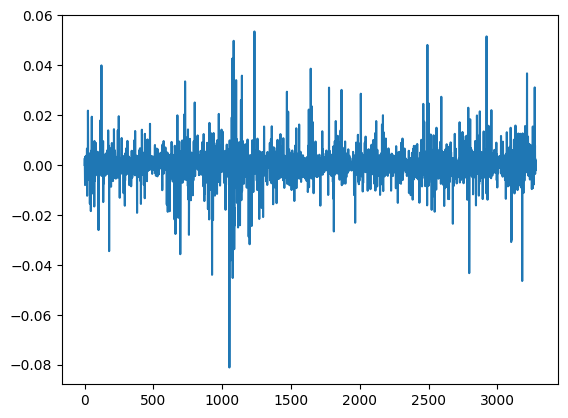

True

In [31]:
import matplotlib.pyplot as plt
plt.plot(get_returns(data, column='close'))
plt.show()
is_data_predictible(data, 'close')

## Percentage of the dataset generating rewards (keep between 5% to 15% or just rely on is_data_predictible())

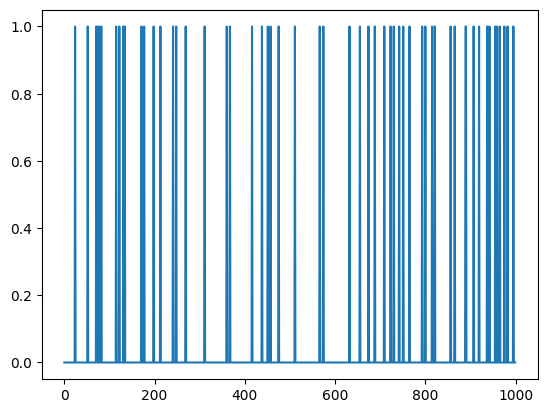

6.83


In [32]:
plt.plot(precalculate_ground_truths(data, column='close').iloc[:1000])
plt.show()
percent_rewardable = round(precalculate_ground_truths(data, column='close').mean() * 100, 2)
print(percent_rewardable)

## Threshold to pass to AnomalousProfit reward scheme

In [33]:
X_train_test = pd.concat([X_train, X_test], axis='index')
threshold = estimate_percent_gains(X_train, 'close')
threshold

0.006908830806193783

## Implement basic feature engineering

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit

In [35]:
rf = RandomForestClassifier(n_estimators=10,
                            random_state=seed,
                            n_jobs=6)

sel = SelectBySingleFeaturePerformance(variables=None,
                                       estimator=rf,
                                       scoring="roc_auc",
                                       cv=TimeSeriesSplit(n_splits=5),
                                       threshold=0.5)

sel.fit(X_train, precalculate_ground_truths(X_train, column='close'))

SelectBySingleFeaturePerformance(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                                 estimator=RandomForestClassifier(n_estimators=10,
                                                                  n_jobs=6,
                                                                  random_state=1337),
                                 threshold=0.5)

In [36]:
feature_performance = pd.Series(sel.feature_performance_).sort_values(ascending=False)
feature_performance

,0
others_dlr,0.968590
others_dr,0.968590
r_volume,0.965812
volume_em,0.712310
volatility_kchi,0.678198
...,...
trend_psar_up,0.462559
trend_visual_ichimoku_b,0.460843
ema_120,0.459814
volume_nvi,0.458781


Text(0, 0.5, 'roc-auc')

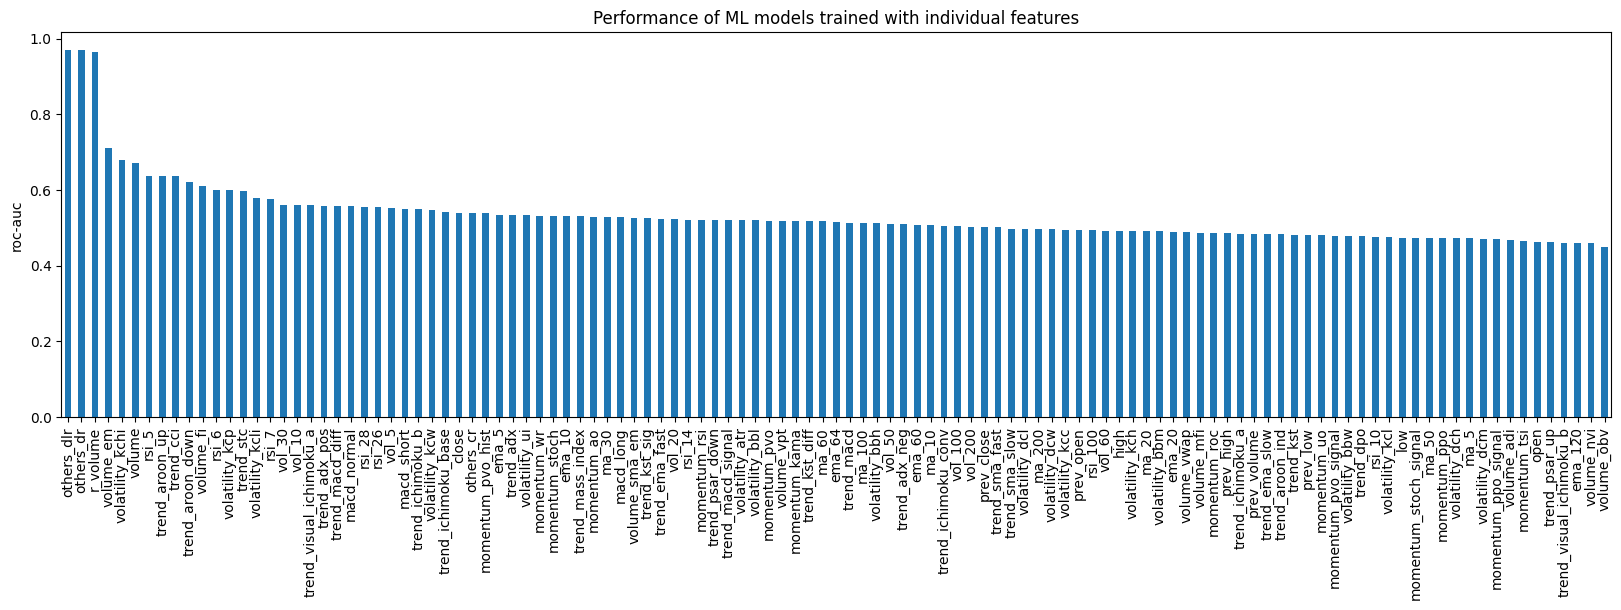

In [37]:
feature_performance.plot.bar(figsize=(20, 5))
plt.title('Performance of ML models trained with individual features')
plt.ylabel('roc-auc')

In [38]:
features_to_drop = sel.features_to_drop_
features_to_drop

['open',
 'high',
 'low',
 'volume_adi',
 'volume_obv',
 'volume_vwap',
 'volume_mfi',
 'volume_nvi',
 'volatility_bbm',
 'volatility_bbw',
 'volatility_kcc',
 'volatility_kch',
 'volatility_kcl',
 'volatility_dcl',
 'volatility_dch',
 'volatility_dcm',
 'volatility_dcw',
 'trend_sma_slow',
 'trend_ema_slow',
 'trend_dpo',
 'trend_kst',
 'trend_ichimoku_a',
 'trend_visual_ichimoku_b',
 'trend_aroon_ind',
 'trend_psar_up',
 'momentum_tsi',
 'momentum_uo',
 'momentum_stoch_signal',
 'momentum_roc',
 'momentum_ppo',
 'momentum_ppo_signal',
 'momentum_pvo_signal',
 'prev_open',
 'prev_high',
 'prev_low',
 'prev_volume',
 'vol_60',
 'ma_5',
 'ma_20',
 'ma_50',
 'ma_200',
 'ema_20',
 'ema_120',
 'rsi_10',
 'rsi_100']

In [39]:
to_drop = list(set(features_to_drop) - set(['open', 'high', 'low', 'close', 'volume']))
len(to_drop)

42

In [40]:
X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)
X_valid = X_valid.drop(columns=to_drop)

X_train.shape, X_test.shape, X_valid.shape

((1098, 74), (1098, 74), (1082, 74))

In [41]:
X_train.columns.tolist()

['date',
 'open',
 'high',
 'low',
 'close',
 'volume',
 'volume_fi',
 'volume_em',
 'volume_sma_em',
 'volume_vpt',
 'volatility_bbh',
 'volatility_bbl',
 'volatility_kcw',
 'volatility_kcp',
 'volatility_kchi',
 'volatility_kcli',
 'volatility_atr',
 'volatility_ui',
 'trend_macd',
 'trend_macd_signal',
 'trend_macd_diff',
 'trend_sma_fast',
 'trend_ema_fast',
 'trend_mass_index',
 'trend_kst_sig',
 'trend_kst_diff',
 'trend_ichimoku_conv',
 'trend_ichimoku_base',
 'trend_ichimoku_b',
 'trend_stc',
 'trend_adx',
 'trend_adx_pos',
 'trend_adx_neg',
 'trend_cci',
 'trend_visual_ichimoku_a',
 'trend_aroon_up',
 'trend_aroon_down',
 'trend_psar_down',
 'momentum_rsi',
 'momentum_stoch',
 'momentum_wr',
 'momentum_ao',
 'momentum_pvo',
 'momentum_pvo_hist',
 'momentum_kama',
 'others_dr',
 'others_dlr',
 'others_cr',
 'prev_close',
 'vol_5',
 'vol_10',
 'vol_20',
 'vol_30',
 'vol_50',
 'vol_100',
 'vol_200',
 'ma_10',
 'ma_30',
 'ma_60',
 'ma_100',
 'ema_5',
 'ema_10',
 'ema_60',
 'ema_64

## Normalize the dataset subsets to make the model converge faster

In [42]:
from sklearn.preprocessing import MinMaxScaler

scaler_type = MinMaxScaler

def get_feature_scalers(X, scaler_type=scaler_type):
    scalers = []
    for name in list(X.columns[X.columns != 'date']):
        scalers.append(scaler_type().fit(X[name].values.reshape(-1, 1)))
    return scalers

def get_scaler_transforms(X, scalers):
    X_scaled = []
    for name, scaler in zip(list(X.columns[X.columns != 'date']), scalers):
        X_scaled.append(scaler.transform(X[name].values.reshape(-1, 1)))
    X_scaled = pd.concat([pd.DataFrame(column, columns=[name]) for name, column in \
                          zip(list(X.columns[X.columns != 'date']), X_scaled)], axis='columns')
    return X_scaled

def normalize_data(X_train, X_test, X_valid):
    X_train_test = pd.concat([X_train, X_test], axis='index')
    X_train_test_valid = pd.concat([X_train_test, X_valid], axis='index')

    X_train_test_dates = X_train_test[['date']]
    X_train_test_valid_dates = X_train_test_valid[['date']]

    X_train_test = X_train_test.drop(columns=['date'])
    X_train_test_valid = X_train_test_valid.drop(columns=['date'])

    train_test_scalers = \
        get_feature_scalers(X_train_test,
                            scaler_type=scaler_type)

    X_train_test_scaled = \
        get_scaler_transforms(X_train_test,
                              train_test_scalers)
    X_train_test_valid_scaled = \
        get_scaler_transforms(X_train_test_valid,
                              train_test_scalers)

    X_train_test_scaled = \
        pd.concat([X_train_test_dates,
                   X_train_test_scaled],
                  axis='columns')
    X_train_test_valid_scaled = \
        pd.concat([X_train_test_valid_dates,
                   X_train_test_valid_scaled],
                  axis='columns')

    X_train_scaled = X_train_test_scaled.iloc[:X_train.shape[0]]
    X_test_scaled = X_train_test_scaled.iloc[X_train.shape[0]:]
    X_valid_scaled = X_train_test_valid_scaled.iloc[X_train_test.shape[0]:]

    return (train_test_scalers,
            X_train_scaled,
            X_test_scaled,
            X_valid_scaled)

In [43]:
train_test_scalers, X_train_scaled, X_test_scaled, X_valid_scaled = \
    normalize_data(X_train, X_test, X_valid)

## Write a reward scheme encouraging rare volatile upside trades

In [44]:
from tensortrade.env.default.rewards import PBR


/content/tensortrade/tensortrade/env/default/rewards.py:186: SyntaxWarning: invalid escape sequence '\c'
  :math:`R_{t} = (p_{t} - p_{t-1}) \cdot x_{t}`.


## Setup Trading Environment

In [45]:
import tensortrade.env.default as default

from tensortrade.feed.core import DataFeed, Stream
from tensortrade.feed.core.base import NameSpace
from tensortrade.env.default.actions import BSH
from tensortrade.oms.exchanges import Exchange, ExchangeOptions
from tensortrade.oms.services.execution.simulated import execute_order
from tensortrade.oms.instruments import USD, AAPL
from tensortrade.oms.wallets import Wallet, Portfolio

commission = 0.001
price = Stream.source(list(X_train["close"]),
                      dtype="float").rename("USD-AAPL")
nasdaq = Exchange("nasdaq",
                  service=execute_order, options=ExchangeOptions(commission=commission))(price)

cash = Wallet(nasdaq, 50000 * USD)
asset = Wallet(nasdaq, 0 * AAPL)

portfolio = Portfolio(USD, [cash, asset])

with NameSpace("nasdaq"):
    features = [
        Stream.source(list(X_train_scaled[c]),
                      dtype="float").rename(c) for c in X_train_scaled.columns[1:]
    ]

feed: DataFeed = DataFeed(features)
feed.compile()

renderer_feed = DataFeed([
    Stream.source(list(X_train["date"])).rename("date"),
    Stream.source(list(X_train["open"]), dtype="float").rename("open"),
    Stream.source(list(X_train["high"]), dtype="float").rename("high"),
    Stream.source(list(X_train["low"]), dtype="float").rename("low"),
    Stream.source(list(X_train["close"]), dtype="float").rename("close"),
    Stream.source(list(X_train["volume"]), dtype="float").rename("volume")
])

action_scheme = BSH(
    cash=cash,
    asset=asset
)

reward_scheme = PBR(price)
action_scheme.attach(reward_scheme)

env = default.create(
    portfolio=portfolio,
    action_scheme=action_scheme,
    reward_scheme=reward_scheme,
    feed=feed,
    renderer_feed=renderer_feed,
    renderer=default.renderers.PlotlyTradingChart(),
    window_size=30
)

In [46]:
env.observer.feed.next()

{'internal': {'nasdaq:/USD-AAPL': 226.45269775390625,
  'nasdaq:/USD:/free': 50000.0,
  'nasdaq:/USD:/locked': 0.0,
  'nasdaq:/USD:/total': 50000.0,
  'nasdaq:/AAPL:/free': 0.0,
  'nasdaq:/AAPL:/locked': 0.0,
  'nasdaq:/AAPL:/total': 0.0,
  'nasdaq:/AAPL:/worth': 0.0,
  'net_worth': 50000.0},
 'external': {'nasdaq:/open': 0.5031381489153175,
  'nasdaq:/high': 0.4966336207019557,
  'nasdaq:/low': 0.5204544497069101,
  'nasdaq:/close': 0.5050107780353441,
  'nasdaq:/volume': 0.034314132798216435,
  'nasdaq:/volume_fi': 0.6359577943594197,
  'nasdaq:/volume_em': 0.3842858305481171,
  'nasdaq:/volume_sma_em': 0.4527576126229001,
  'nasdaq:/volume_vpt': 0.7821874550826968,
  'nasdaq:/volatility_bbh': 0.40693415391521315,
  'nasdaq:/volatility_bbl': 0.5409046300394129,
  'nasdaq:/volatility_kcw': 0.1075085237851438,
  'nasdaq:/volatility_kcp': 0.6239801785145863,
  'nasdaq:/volatility_kchi': 0.0,
  'nasdaq:/volatility_kcli': 0.0,
  'nasdaq:/volatility_atr': 0.11286702566330484,
  'nasdaq:/vo

## Setup and Train DQN Agent

In [47]:
def get_optimal_batch_size(window_size=30, n_steps=1000, batch_factor=4, stride=1):
    """
    lookback = 30
    batch_factor = 4
    stride = 1
    """
    lookback = window_size
    sample_size = n_steps
    batch_size = ((sample_size - lookback - stride) // batch_factor)
    return batch_size

batch_size = get_optimal_batch_size(window_size=window_size, n_steps=n_steps, batch_factor=4)
batch_size

242

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import namedtuple, deque
import random

DQNTransition = namedtuple('DQNTransition', ['state', 'action', 'reward', 'next_state', 'done'])

class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, *args):
        self.memory.append(DQNTransition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

class DQNNetwork(nn.Module):
    def __init__(self, input_shape, n_actions):
        super(DQNNetwork, self).__init__()
        n_features = input_shape[1] if len(input_shape) > 1 else input_shape[0]
        self.conv1 = nn.Conv1d(n_features, 32, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=4, stride=2, padding=1)
        self.conv3 = nn.Conv1d(64, 64, kernel_size=4, stride=2, padding=1)

        self.prelu1 = nn.PReLU()
        self.prelu2 = nn.PReLU()
        self.prelu3 = nn.PReLU()

        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn3 = nn.BatchNorm1d(64)

        self.gru = nn.GRU(64, 64, batch_first=True)

        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, n_actions)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.permute(0, 2, 1)

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.prelu1(x)
        x = self.dropout(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.prelu2(x)
        x = self.dropout(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.prelu3(x)
        x = self.dropout(x)

        x = x.permute(0, 2, 1)
        _, h_n = self.gru(x)
        x = h_n.squeeze(0)

        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

class PyTorchDQNAgent:
    def __init__(self, env, device='cuda'):
        self.env = env
        self.device = torch.device(device if torch.cuda.is_available() else 'cpu')
        self.n_actions = int(env.action_space.n)
        self.observation_shape = env.observation_space.shape

        self.policy_net = DQNNetwork(self.observation_shape, self.n_actions).to(self.device)
        self.target_net = DQNNetwork(self.observation_shape, self.n_actions).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=0.001)

    def get_action(self, state, epsilon=0.0):
        if random.random() < epsilon:
            return random.randint(0, self.n_actions - 1)
        else:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
                q_values = self.policy_net(state_t)
                return q_values.argmax(dim=1).item()

    def optimize_model(self, batch_size, gamma=0.99):
        if len(self.memory) < batch_size:
            return

        transitions = self.memory.sample(batch_size)
        batch = DQNTransition(*zip(*transitions))

        state_batch = torch.FloatTensor(np.array(batch.state)).to(self.device)
        action_batch = torch.LongTensor(batch.action).to(self.device)
        reward_batch = torch.FloatTensor(batch.reward).to(self.device)
        next_state_batch = torch.FloatTensor(np.array(batch.next_state)).to(self.device)
        done_batch = torch.FloatTensor(np.array(batch.done, dtype=np.float32)).to(self.device)

        state_action_values = self.policy_net(state_batch).gather(1, action_batch.unsqueeze(1))

        with torch.no_grad():
            next_state_values = self.target_net(next_state_batch).max(1)[0]
            expected_state_action_values = (next_state_values * gamma * (1 - done_batch)) + reward_batch

        loss = nn.SmoothL1Loss()(state_action_values.squeeze(), expected_state_action_values)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def train(self, n_steps=1000, n_episodes=20, batch_size=32, memory_capacity=10000,
              save_path='agents/', gamma=0.99, eps_start=0.9, eps_end=0.05, eps_decay=200):
        self.memory = ReplayMemory(memory_capacity)
        steps_done = 0

        for episode in range(n_episodes):
            state, _ = self.env.reset()



            episode_reward = 0
            episode_losses = []

            for step in range(n_steps):
                eps_threshold = eps_end + (eps_start - eps_end) * \
                    np.exp(-steps_done / eps_decay)

                action = self.get_action(state, eps_threshold)

                next_state, reward, terminated, truncated, _ = self.env.step(action)


                done = terminated or truncated



                self.memory.push(state, action, reward, next_state, done)

                state = next_state
                episode_reward += reward
                steps_done += 1

                loss = self.optimize_model(batch_size, gamma)
                if loss is not None:
                    episode_losses.append(loss)

                if steps_done % 100 == 0:
                    self.target_net.load_state_dict(self.policy_net.state_dict())

                if done:
                    break

            avg_loss = np.mean(episode_losses) if episode_losses else 0
            print(f'Episode {episode + 1}/{n_episodes}, Reward: {episode_reward:.2f}, Loss: {avg_loss:.4f}, Steps: {step + 1}')

            if save_path and (episode + 1) % 5 == 0:
                torch.save(self.policy_net.state_dict(), f'{save_path}dqn_model_ep{episode + 1}.pth')

agent = PyTorchDQNAgent(env, device='cuda')
agent.optimizer = torch.optim.Adam(agent.policy_net.parameters(), lr=learning_rate)

os.makedirs(save_path, exist_ok=True)
agent.train(n_steps=n_steps,
            n_episodes=n_episodes,
            batch_size=batch_size,
            memory_capacity=memory_capacity,
            save_path=save_path,
            gamma=gamma,
            eps_decay=eps_decay)

Episode 1/20, Reward: 12.56, Loss: 0.4171, Steps: 1000


## Implement validation here

In [ ]:
def validate_agent(agent, X_data, X_data_scaled, window_size=30):
    from tensortrade.feed.core import DataFeed, Stream
    from tensortrade.feed.core.base import NameSpace
    from tensortrade.oms.exchanges import ExchangeOptions

    price_stream = Stream.source(list(X_data["close"]), dtype="float").rename("USD-AAPL")
    val_exchange = Exchange("nasdaq", service=execute_order, options=ExchangeOptions(commission=commission))(price_stream)
    val_cash = Wallet(val_exchange, 50000 * USD)
    val_asset = Wallet(val_exchange, 0 * AAPL)
    val_portfolio = Portfolio(USD, [val_cash, val_asset])

    with NameSpace("nasdaq"):
        val_features = [
            Stream.source(list(X_data_scaled[c]), dtype="float").rename(c)
            for c in X_data_scaled.drop(columns=['date'], errors='ignore').columns
        ]

    val_feed: DataFeed = DataFeed(val_features)
    val_feed.compile()

    val_renderer_feed = DataFeed([
        Stream.source(list(X_data["date"])).rename("date"),
        Stream.source(list(X_data["open"]), dtype="float").rename("open"),
        Stream.source(list(X_data["high"]), dtype="float").rename("high"),
        Stream.source(list(X_data["low"]), dtype="float").rename("low"),
        Stream.source(list(X_data["close"]), dtype="float").rename("close"),
        Stream.source(list(X_data["volume"]), dtype="float").rename("volume")
    ])

    val_action_scheme = BSH(cash=val_cash, asset=val_asset)
    val_reward_scheme = PBR(price_stream)
    val_action_scheme.attach(val_reward_scheme)
    val_env = default.create(
        portfolio=val_portfolio,
        action_scheme=val_action_scheme,
        reward_scheme=val_reward_scheme,
        feed=val_feed,
        renderer_feed=val_renderer_feed,
        window_size=window_size
    )

    val_agent = PyTorchDQNAgent(val_env, device='cuda')
    val_agent.policy_net.load_state_dict(agent.policy_net.state_dict())
    val_agent.policy_net.eval()
    val_agent.target_net.load_state_dict(agent.target_net.state_dict())
    val_agent.target_net.eval()

    state, _ = val_env.reset()

    net_worth = [val_env.action_scheme.portfolio.initial_net_worth]
    actions = []
    prices = [X_data.iloc[0]['close']]

    for i in range(1, len(X_data)):
        action = val_agent.get_action(state, epsilon=0.0)
        next_state, reward, terminated, truncated, _ = val_env.step(action)


        done = terminated or truncated

        state = next_state
        nw = val_env.action_scheme.portfolio.net_worth
        net_worth.append(nw)
        actions.append(action)
        prices.append(X_data.iloc[i]['close'])

        if done:
            break

    total_return = (net_worth[-1] / net_worth[0] - 1) * 100
    buy_hold_return = (X_data.iloc[-1]['close'] / X_data.iloc[0]['close'] - 1) * 100

    nw_series = pd.Series(net_worth)
    returns = nw_series.pct_change().dropna()
    sharpe = np.sqrt(252 * 6.5) * returns.mean() / returns.std() if returns.std() > 0 else 0

    trades = sum(1 for i in range(1, len(actions)) if actions[i] != actions[i-1])

    print(f'Total Return: {total_return:.2f}%')
    print(f'Buy & Hold Return: {buy_hold_return:.2f}%')
    print(f'Sharpe Ratio: {sharpe:.2f}')
    print(f'Total Trades: {trades}')
    print(f'Net Worth: {net_worth[0]:.2f} -> {net_worth[-1]:.2f}')

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    axes[0].plot(net_worth, label='Portfolio Value', color='blue')
    axes[0].axhline(y=net_worth[0], color='gray', linestyle='--', alpha=0.5)
    axes[0].set_title('Portfolio Net Worth')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(prices, label='Close Price', color='green')
    axes[1].set_title('Asset Price')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return net_worth, actions, total_return

net_worth, trade_actions, test_return = validate_agent(agent, X_test, X_test_scaled, window_size=window_size)

net_worth_val, trade_actions_val, valid_return = validate_agent(agent, X_valid, X_valid_scaled, window_size=window_size)

In [ ]:
# Trains one agent per hyperparameter combination on a FRESH environment and
# selects the best by validation net-worth return. The search is intentionally
# small; expand `grid` (e.g. add `beta` / `eps_decay` to itertools.product) to
# cover more. For a quick pass, lower `sweep_episodes` / `n_steps` below.
import itertools
import pandas as pd
from tensortrade.oms.exchanges import ExchangeOptions

sweep_episodes = 10  # fewer than the full run; bump up for a more thorough search


def make_env(window_size=window_size):
    """Build a fresh default trading env for one trial.

    A new exchange, wallets, portfolio, feed and action/reward schemes are
    constructed on every call so trials do not leak state into each other.
    """

    price = Stream.source(list(X_train["close"]), dtype="float").rename("USD-AAPL")
    nasdaq = Exchange("nasdaq", service=execute_order, options=ExchangeOptions(commission=commission))(price)

    cash = Wallet(nasdaq, 50000 * USD)
    asset = Wallet(nasdaq, 0 * AAPL)
    portfolio = Portfolio(USD, [cash, asset])

    with NameSpace("nasdaq"):
        features = [
            Stream.source(list(X_train_scaled[c]), dtype="float").rename(c)
            for c in X_train_scaled.columns[1:]
        ]

    feed = DataFeed(features)
    feed.compile()

    renderer_feed = DataFeed([
        Stream.source(list(X_train["date"])).rename("date"),
        Stream.source(list(X_train["open"]), dtype="float").rename("open"),
        Stream.source(list(X_train["high"]), dtype="float").rename("high"),
        Stream.source(list(X_train["low"]), dtype="float").rename("low"),
        Stream.source(list(X_train["close"]), dtype="float").rename("close"),
        Stream.source(list(X_train["volume"]), dtype="float").rename("volume"),
    ])

    action_scheme = BSH(cash=cash, asset=asset)
    reward_scheme = PBR(price)
    action_scheme.attach(reward_scheme)

    env = default.create(
        portfolio=portfolio,
        action_scheme=action_scheme,
        reward_scheme=reward_scheme,
        feed=feed,
        renderer_feed=renderer_feed,
        renderer=default.renderers.EmptyRenderer(),
        window_size=window_size,
    )
    return env


def run_trial(lr, gamma, eps_decay,
              n_steps=n_steps, n_episodes=sweep_episodes, window_size=window_size):
    """Train one agent and return its validation/test net-worth returns."""
    env = make_env(window_size=window_size)
    agent = PyTorchDQNAgent(env, device="cuda")
    agent.optimizer = torch.optim.Adam(agent.policy_net.parameters(), lr=lr)
    agent.train(
        n_steps=n_steps,
        n_episodes=n_episodes,
        batch_size=batch_size,
        memory_capacity=memory_capacity,
        save_path=None,
        gamma=gamma,
        eps_decay=eps_decay,
    )
    _, _, valid_return = validate_agent(agent, X_valid, X_valid_scaled, window_size=window_size)
    _, _, test_return = validate_agent(agent, X_test, X_test_scaled, window_size=window_size)
    return {
        "lr": lr, "gamma": gamma, "eps_decay": eps_decay,

        "valid_return": valid_return, "test_return": test_return,
    }


# Small explicit grid: learning_rate x discount x reward c_up.
# Add `beta` / `eps_decay` to itertools.product to tune them too.
grid = list(itertools.product([1e-3, 5e-4], [0.99, 0.95], [100, 200, 500]))

results = []
for lr, gamma, eps_decay_val in grid:
    print(f"Trial lr={lr} gamma={gamma} eps_decay={eps_decay_val} ...")
    results.append(run_trial(lr=lr, gamma=gamma, eps_decay=eps_decay_val))

results_df = (
    pd.DataFrame(results)
    .sort_values("valid_return", ascending=False)
    .reset_index(drop=True)
)
print("\nSweep results (sorted by validation return):")
print(results_df.to_string(index=False))

best = results_df.iloc[0]
print(
    f"\nBest config: lr={best.lr} gamma={best.gamma} eps_decay={best.eps_decay} "
    f""
    f"test={best.test_return:.2f}%"
)

# Retrain the best config (saving checkpoints) and report once more.
best_env = make_env(window_size=window_size)
best_agent = PyTorchDQNAgent(best_env, device="cuda")
best_agent.optimizer = torch.optim.Adam(best_agent.policy_net.parameters(), lr=float(best.lr))
os.makedirs(save_path, exist_ok=True)
best_agent.train(
    n_steps=n_steps, n_episodes=n_episodes, batch_size=batch_size,
    memory_capacity=memory_capacity, save_path=save_path,
    gamma=float(best.gamma), eps_decay=float(best.eps_decay),
)
net_worth, trade_actions, test_return = validate_agent(best_agent, X_test, X_test_scaled, window_size=window_size)
net_worth_val, trade_actions_val, valid_return = validate_agent(best_agent, X_valid, X_valid_scaled, window_size=window_size)
print(f"Best agent retrained -> valid={valid_return:.2f}% test={test_return:.2f}%")

# Persist the winning hyperparameters so re-running the training cell uses them.
learning_rate = float(best.lr)
gamma = float(best.gamma)
eps_decay = int(best.eps_decay)

print(f"Updated globals -> learning_rate={learning_rate} gamma={gamma} eps_decay={eps_decay}")

## Print basic quantstats report

In [ ]:
returns = pd.Series(net_worth).pct_change().dropna()

print('===== Quantstats Performance Report =====')
print(f'Start Date: {X_test.iloc[window_size]["date"]}')
print(f'End Date: {X_test.iloc[-1]["date"]}')
print(f'Duration: {len(returns)} periods')
print()
print(f'Total Return: {test_return:.2f}%')
print(f'Buy & Hold Return: {(X_test.iloc[-1]["close"] / X_test.iloc[window_size]["close"] - 1) * 100:.2f}%')
print()
print(f'Cumulative Return: {(pd.Series(net_worth).iloc[-1] / pd.Series(net_worth).iloc[0] - 1) * 100:.2f}%')
print(f'Annual Return: {returns.mean() * 252 * 6.5 * 100:.2f}%')
print(f'Annual Volatility: {returns.std() * np.sqrt(252 * 6.5) * 100:.2f}%')
print(f'Sharpe Ratio: {np.sqrt(252 * 6.5) * returns.mean() / returns.std():.2f}' if returns.std() > 0 else 'Sharpe Ratio: N/A')
print(f'Max Drawdown: {(pd.Series(net_worth) / pd.Series(net_worth).cummax() - 1).min() * 100:.2f}%')
print()
print(f'Best Day: {returns.max() * 100:.2f}%')
print(f'Worst Day: {returns.min() * 100:.2f}%')
print(f'Total Trades: {sum(1 for i in range(1, len(trade_actions)) if trade_actions[i] != trade_actions[i-1])}')